In [1]:
import numpy as np
import matplotlib.pyplot as plt
import load_mnist

In [3]:
# load data using functions coded in load_mnist.py
y_train = load_mnist.load_labels(load_mnist.f_training_labels)
X_train = np.hstack((load_mnist.load_images(load_mnist.f_training_images), np.ones((len(y_train),1))))/255.0

y_test = load_mnist.load_labels(load_mnist.f_test_labels)
X_test = np.hstack((load_mnist.load_images(load_mnist.f_test_images), np.ones((len(y_test),1))))/255.0

In [60]:
def train_svm_sgd(X, y, lam, n_batch):
    """Stochastic gradient descent algorithm for classifying handwritten digits
    
    Randomly selects n_batch records from the training data and processes as a minibatch. 
    
    """
    
    # parameters for SVM-SGD algorithm
    n_total = len(y)    
    
    w = np.zeros((len(X_train[0]),10))
    
    for k in range(10000):
       
        # randomly choose indices from the original data for the minibatch
        minibatch_indices = np.random.randint(0, n_total, n_batch)
        X_batch = X_train[minibatch_indices]
        y_batch = load_mnist.digit_2_matrix(y_train[minibatch_indices])

        # diminishing tau
        tau = 1/np.sqrt(100*(k+1))

        # calculate the indicator value
        dxw = np.multiply(y_batch, X_batch@w)    

        # calculate the gradient -- the boolean operation evaluates to 0,1
        grad_sum = -np.multiply(dxw.T<1, y_batch.T)@X_batch

        w_new = w - tau * (grad_sum.T + 2*lam/(n_total/n_batch)*w)
        w = w_new
    
    return w

# Test performance with $10^{-4} \leq \lambda \leq 10^{2}$

In [61]:
lam_arr = np.logspace(-4,2,10)
err_train = np.zeros(len(lam_arr))
err_test = np.zeros(len(lam_arr))

# loop 10 times to average results
for j in range(10):
    
    for i, lam in enumerate(lam_arr):

        # train the model using the training set
        w = train_svm_sgd(X_train, y_train, lam, 50)

        # demonstrate the model error with the training data
        y_hat = load_mnist.matrix_2_digit(X_train@w)
        err_train[i] += 1 - np.sum(y_hat==y_train) / len(y_train)

        # use the test set to measure error
        y_hat = load_mnist.matrix_2_digit(X_test@w)
        err_test[i] += 1 - np.sum(y_hat==y_test) / len(y_test)

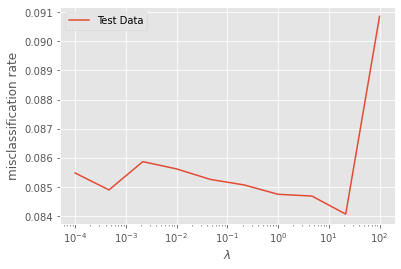

In [62]:
#plt.plot(lam_arr, err_train/10, label='Training Data')
plt.plot(lam_arr, err_test/10, label='Test Data')

plt.xlabel(r'$\lambda$')
plt.ylabel('misclassification rate')

plt.semilogx()
plt.legend()

# Test performance with $10 \leq \text{minibatch } n \leq 1000$

In [63]:
n_batch_arr = [10, 25, 50, 100, 250, 500, 1000]
err_train = np.zeros(len(n_batch_arr))
err_test = np.zeros(len(n_batch_arr))

# loop 10 times to average results
for j in range(10):
    
    for i, n in enumerate(n_batch_arr):

        # train the model using the training set
        w = train_svm_sgd(X_train, y_train, 10, n)

        # demonstrate the model error with the training data
        y_hat = load_mnist.matrix_2_digit(X_train@w)
        err_train[i] += 1 - np.sum(np.equal(y_hat, y_train)) / len(y_train)

        # use the test set to measure error
        y_hat = load_mnist.matrix_2_digit(X_test@w)
        err_test[i] += 1 - np.sum(np.equal(y_hat, y_test)) / len(y_test)

0.0827


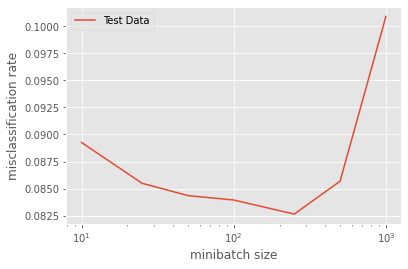

In [64]:
#plt.plot(n_batch_arr, err_train/10, label='Training Data')
plt.plot(n_batch_arr, err_test/10, label='Test Data')

plt.xlabel('minibatch size')
plt.ylabel('misclassification rate')

plt.semilogx()
plt.legend()

print(np.round(min(err_test)/10,4))

# Explore bias of classifier

In [65]:
import pandas as pd

# weight matrix m-rows x 10-cols, column represents weights for classifying that digit
error_by_digit = np.zeros(10)

for i in range(100):
    w = train_svm_sgd(X_train, y_train, 10, 100)

    # test using test dataset
    y_hat = load_mnist.matrix_2_digit(X_test@w)
    error_rate = 1-np.sum(np.equal(y_hat, y_test)) / len(y_test)

    #print('Error rate: {:0.1%}'.format(error_rate))

    df = pd.DataFrame(data=np.hstack((y_test, np.equal(y_hat,y_test))), columns=['digit', 'correct'])
    pt = df.pivot_table(index='digit', values=['correct', 'correct'], aggfunc=[len, np.sum])
    pt = pt.stack().reset_index()
    error_by_digit += 0.01 * (1-pt['sum']/pt['len'])

Text(0, 0.5, 'misclassification rate')

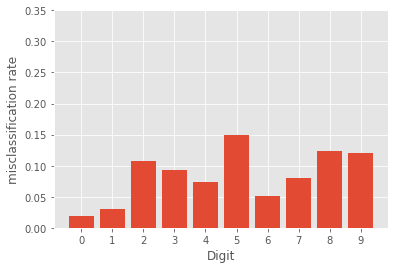

In [66]:
plt.bar(range(10), error_by_digit)
plt.xticks(range(10))
plt.xlabel('Digit')
plt.ylim(0,.35)
plt.ylabel('misclassification rate')